In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("default")

In [2]:
df=pd.read_csv(r"C:\Users\Acer\Desktop\data_science_project\Covid_19_data_analysis\data\covid_data.csv")
df.head()
df.shape
df.info

<bound method DataFrame.info of           date country  confirmed  deaths  recovered
0   2020-03-01   India          3       0          0
1   2020-03-05   India         29       0          3
2   2020-03-10   India         62       1          4
3   2020-03-15   India        114       2         13
4   2020-03-20   India        258       4         23
5   2020-03-25   India        657      12         43
6   2020-03-30   India       1251      32        102
7   2020-04-05   India       3588      99        229
8   2020-04-10   India       7599     249        774
9   2020-03-01     USA         75       1          7
10  2020-03-05     USA        159      11          8
11  2020-03-10     USA        472      19          8
12  2020-03-15     USA       1678      41        121
13  2020-03-20     USA      19100     244        147
14  2020-03-25     USA      65778     942        361
15  2020-03-30     USA     163539    2978       5645
16  2020-04-05     USA     337072    9619      17448
17  2020-04-10

In [ ]:
#converting date column to datetime format
df['date']=pd.to_datetime(df['date'])
df.dtypes

date         datetime64[ns]
country              object
confirmed             int64
deaths                int64
recovered             int64
dtype: object

In [4]:
df.describe()

,date,confirmed,deaths,recovered
count,27,27.000000,27.000000,27.000000
mean,2020-03-20 08:00:00,60641.666667,3455.185185,5082.444444
min,2020-03-01 00:00:00,3.000000,0.000000,0.000000
25%,2020-03-10 00:00:00,365.000000,11.500000,18.000000
50%,2020-03-20 00:00:00,3588.000000,107.000000,229.000000
75%,2020-03-30 00:00:00,70082.000000,3505.000000,5042.500000
max,2020-04-10 00:00:00,496535.000000,18849.000000,30455.000000
std,NaN,115960.243931,6024.914701,9091.724996


In [5]:
df["country"].unique()

array(['India', 'USA', 'Italy'], dtype=object)

In [6]:
#countrywise total confirmed cases
country_cases=(df.groupby("country")["confirmed"].max().sort_values(ascending=False))
country_cases

country
USA      496535
Italy    147577
India      7599
Name: confirmed, dtype: int64

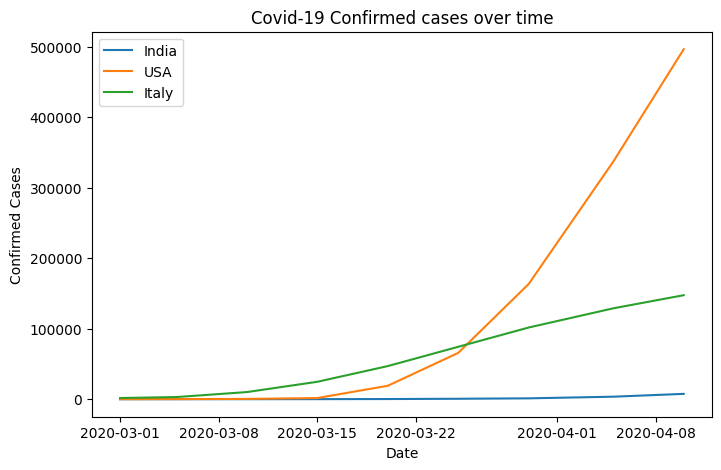

In [8]:
#trend over time
plt.figure(figsize=(8,5))
for country in df["country"].unique():
    country_data=df[df["country"]==country]
    plt.plot(country_data["date"],country_data["confirmed"],label=country)
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.title("Covid-19 Confirmed cases over time")
plt.legend()
plt.show()

In [9]:
#death vs recoveries
country_summary=df.groupby("country")[["deaths","recovered"]].max()
country_summary

,deaths,recovered
country,,
India,249,774
Italy,18849,30455
USA,18586,27900


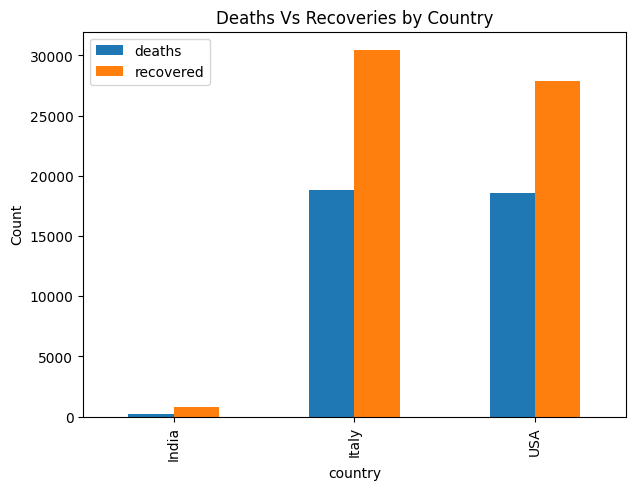

In [10]:
country_summary.plot(kind="bar",figsize=(7,5))
plt.title("Deaths Vs Recoveries by Country")
plt.ylabel("Count")
plt.show()

In [11]:
#Case Fatality Rate
country_summary["fatality_rate"]=(country_summary["deaths"]/country_cases)*100
country_summary[["fatality_rate"]]

,fatality_rate
country,
India,3.276747
Italy,12.772315
USA,3.743140
